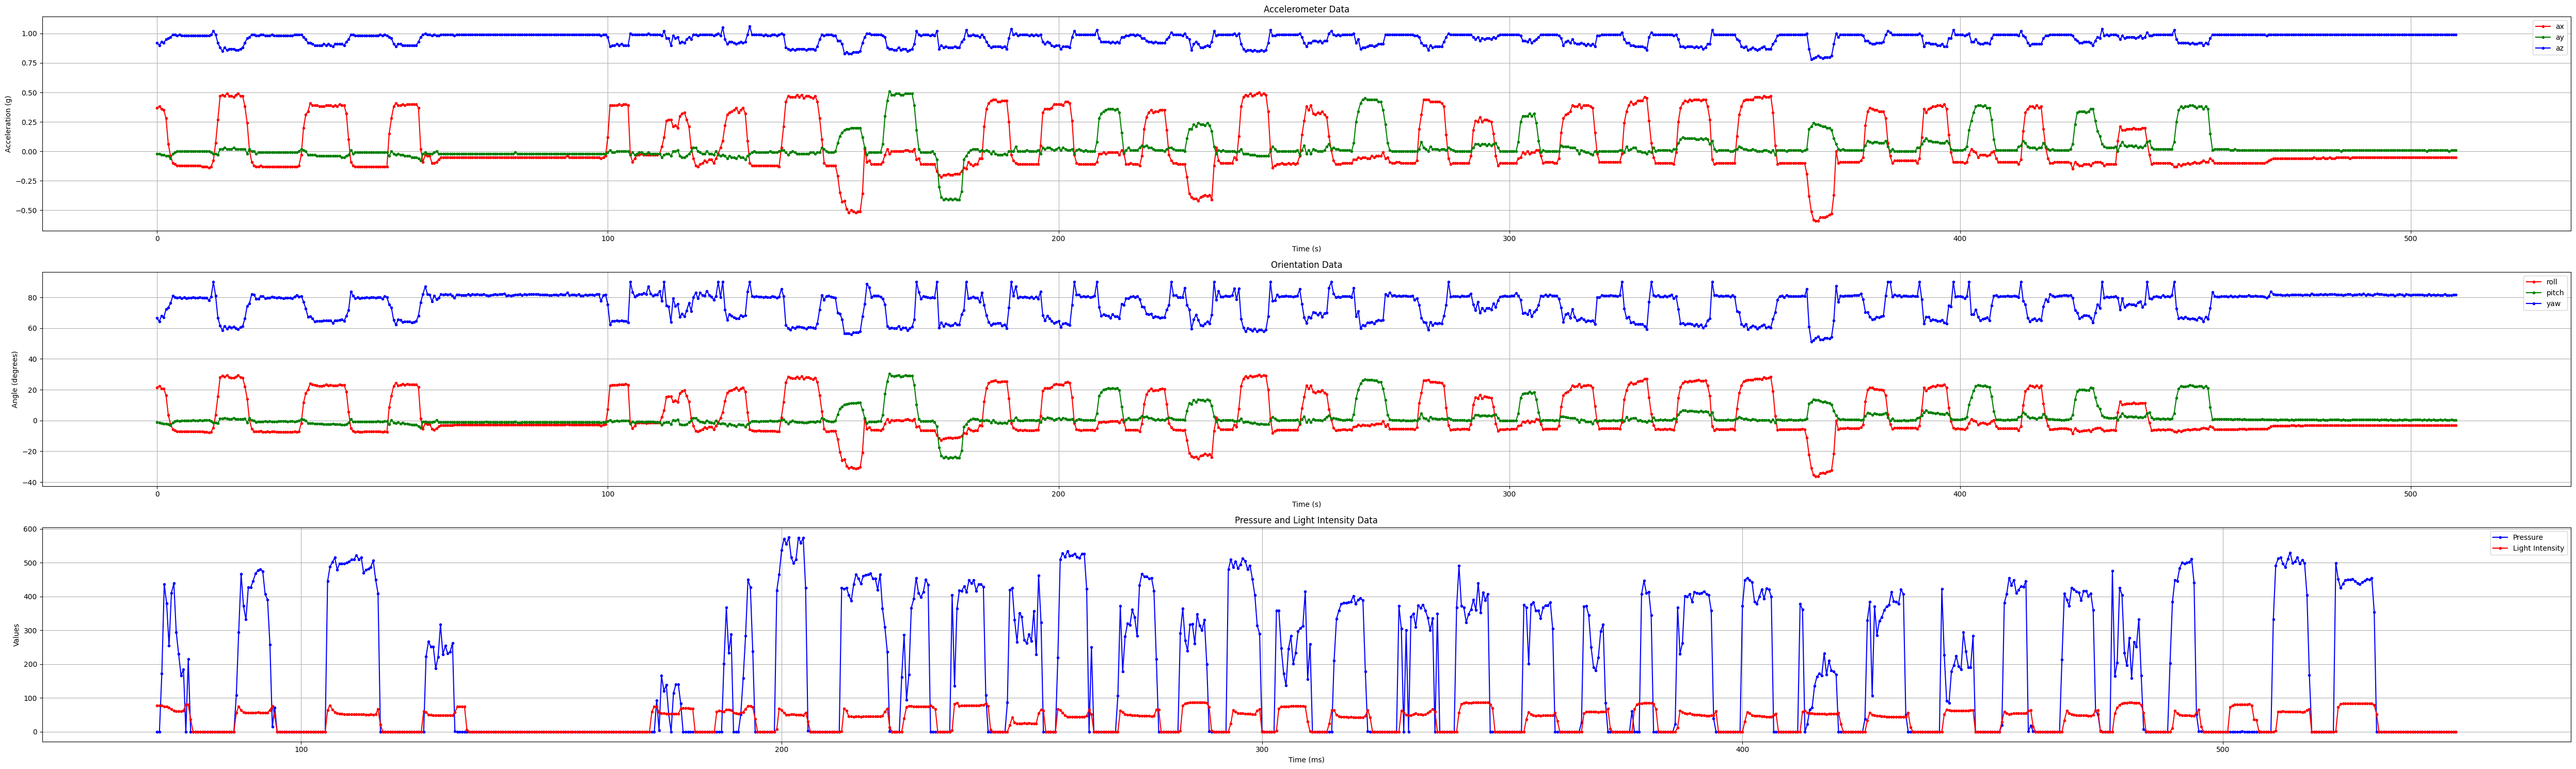

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Part 1: Plot IMU data
# Define file path for IMU data
imu_file_path = "data_IMU.txt"

# Read the IMU data
imu_df = pd.read_csv(imu_file_path, header=None, names=["ax", "ay", "az", "r", "p", "y"])
imu_df = imu_df[80:]
# Create a time column (assuming 0.5s per row)
imu_df["Time"] = [i * 0.5 for i in range(len(imu_df))]

# Part 2: Plot Pressure and Light data
# Define file path for pressure and light data
press_light_file_path = "data_press_light.txt"

# Read the pressure and light data as provided
press_light_df = pd.read_csv(press_light_file_path, delim_whitespace=True, header=None, 
                            names=["Time (ms)", "Pressure", "Light Intensity (lux)", "Unit"])
press_light_df = press_light_df[139:]
# Drop the unnecessary unit column
press_light_df = press_light_df.drop(columns=["Unit"])

# Convert time from milliseconds to seconds
press_light_df["Time (ms)"] = press_light_df["Time (ms)"] / 1000

# Create a figure with three subplots
plt.figure(figsize=(50, 15))

# Plot 1: Accelerometer data
plt.subplot(3, 1, 1)
plt.plot(imu_df["Time"], imu_df["ax"], marker='.', linestyle='-', color='r', label="ax")
plt.plot(imu_df["Time"], imu_df["ay"], marker='.', linestyle='-', color='g', label="ay")
plt.plot(imu_df["Time"], imu_df["az"], marker='.', linestyle='-', color='b', label="az")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Accelerometer Data")
plt.legend()
plt.grid(True)

# Plot 2: Orientation data
plt.subplot(3, 1, 2)
plt.plot(imu_df["Time"], imu_df["r"], marker='.', linestyle='-', color='r', label="roll")
plt.plot(imu_df["Time"], imu_df["p"], marker='.', linestyle='-', color='g', label="pitch")
plt.plot(imu_df["Time"], imu_df["y"], marker='.', linestyle='-', color='b', label="yaw")
plt.xlabel("Time (s)")
plt.ylabel("Angle (degrees)")
plt.title("Orientation Data")
plt.legend()
plt.grid(True)

# Plot 3: Pressure and Light Intensity
plt.subplot(3, 1, 3)
plt.plot(press_light_df["Time (ms)"], press_light_df["Pressure"], marker='.', 
         linestyle='-', color='b', label="Pressure")
plt.plot(press_light_df["Time (ms)"], press_light_df["Light Intensity (lux)"], marker='.', 
         linestyle='-', color='r', label="Light Intensity")
plt.xlabel("Time (ms)")
plt.ylabel("Values")
plt.title("Pressure and Light Intensity Data")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()